# Trích xuất bảng từ ảnh tài liệu
> Grayscale → Deskew → CLAHE → Otsu Binarization → Morphological Line Extraction →
> Contour Detection → Grid Reconstruction → Cell Cropping → OCR

# Import thư viện

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap="gray", figsize=(10, 12)):
    plt.figure(figsize=figsize)
    if img.ndim == 3:                     
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap, vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_row(images, titles, figsize=(16, 8)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i, (im, t) in enumerate(zip(images, titles)):
        plt.subplot(1, n, i + 1)
        if im.ndim == 3:
            plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(im, cmap="gray", vmin=0, vmax=255)
        plt.title(t)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Import ảnh

Đổi `IMG_PATH` thành đường dẫn tới một ảnh trang trong `training_set`.
Để `None` nếu muốn dùng ảnh bảng giả do notebook tự vẽ (có ô gộp, có chữ, hơi nghiêng).

Shape: (600, 900, 3)
Dtype : uint8


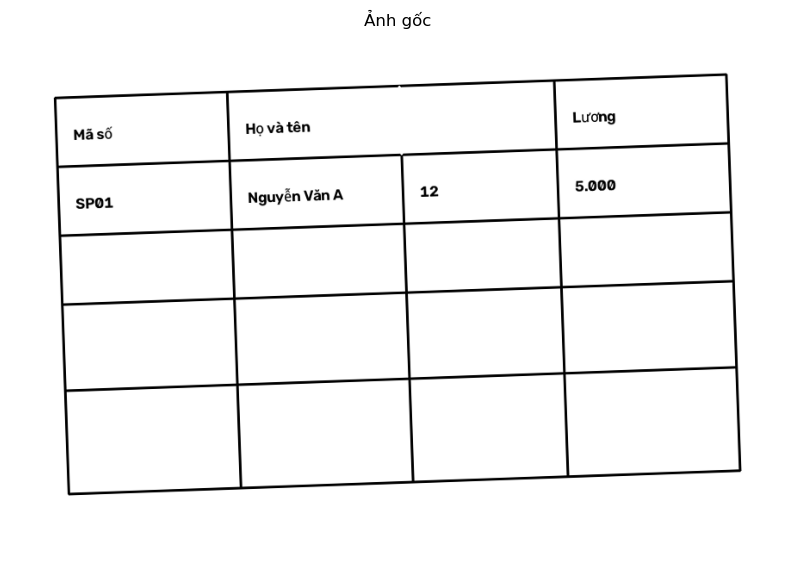

In [4]:
IMG_PATH = None  

# Tạo một ảnh minh họa để xử lý thử khi không có data
def make_fake_table(width=900, height=600, angle=2.0):
    """Vẽ một bảng giả: 4 cột x 5 hàng, có 1 ô gộp ngang ở tiêu đề, rồi xoay nhẹ."""
    img = np.full((height, width), 255, np.uint8)
    x0, y0, x1, y1 = 60, 60, 840, 520
    xs = [60, 260, 460, 640, 840]          # 5 đường dọc -> 4 cột
    ys = [60, 140, 220, 300, 400, 520]     # 6 đường ngang -> 5 hàng

    for y in ys:
        cv2.line(img, (x0, y), (x1, y), 0, 2)
    for x in xs:
        cv2.line(img, (x, y0), (x, y1), 0, 2)

    # Xoá đoạn kẻ dọc giữa cột 2 và cột 3 ở hàng đầu -> tạo ô gộp ngang
    cv2.line(img, (xs[2], ys[0] + 2), (xs[2], ys[1] - 2), 255, 4)

    texts = ["Mã số", "Họ và tên", "", "Lương", "SP01", "Nguyễn Văn A", "12", "5.000"]
    pos = [(80, 110), (280, 110), (0, 0), (660, 110),
           (80, 190), (280, 190), (480, 190), (660, 190)]
    for t, p in zip(texts, pos):
        if t:
            cv2.putText(img, t, p, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 0, 2)

    # Xoay nhẹ cho giống ảnh chụp
    M = cv2.getRotationMatrix2D((width / 2, height / 2), angle, 1.0)
    img = cv2.warpAffine(img, M, (width, height),
                         flags=cv2.INTER_CUBIC, borderValue=255)
    return cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)


if IMG_PATH:
    img = cv2.imread(IMG_PATH)
else:
    img = make_fake_table()

print("Shape:", img.shape)
print("Dtype :", img.dtype)
show(img, "Ảnh gốc")

# 1. Grayscale - chuyển ảnh xám
Cấu trúc bảng nằm ở **độ sáng** chứ không ở màu. Bỏ màu giúp:

- giảm dữ liệu 3 lần (3 kênh → 1 kênh);
- mọi thuật toán phía sau (threshold, morphology) đều làm việc trên ảnh 1 kênh.

Công thức OpenCV dùng: `Y = 0.299*R + 0.587*G + 0.114*B`.
Trọng số không bằng nhau vì mắt người nhạy với màu lục nhất và kém nhạy với màu lam.

Shape (600, 900)


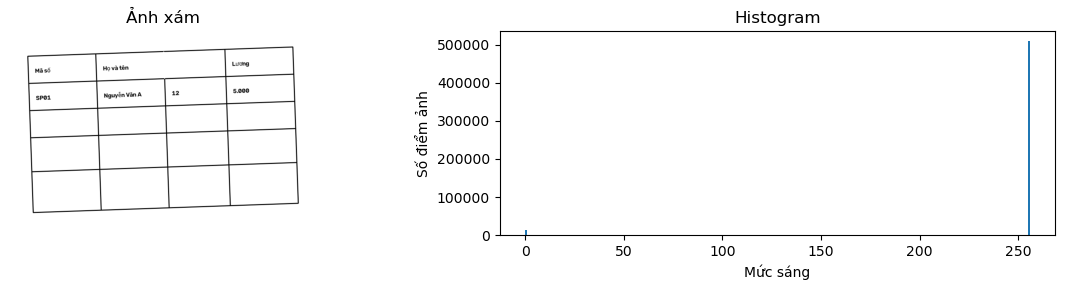

In [5]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print("Shape", gray.shape)

plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1); plt.imshow(gray, cmap="gray"); plt.axis("off"); plt.title("Ảnh xám")
plt.subplot(1, 2, 2); plt.hist(gray.ravel(), bins=256, range=(0, 256))
plt.title("Histogram"); plt.xlabel("Mức sáng"); plt.ylabel("Số điểm ảnh")
plt.tight_layout(); plt.show()

# 2. Deskew - chỉnh nghiêng

Bước 5 sẽ tìm đường kẻ **ngang** và **dọc** bằng kernel dẹt. 

VD: Nếu ảnh nghiêng 3°, một đường kẻ
ngang dài 800 px sẽ lệch khoảng `800 · tan(3°) ≈ 42 px` theo chiều dọc → kernel cao 1 px không
bắt được nó nữa. Vì vậy **phải chỉnh nghiêng trước**.

Hai cách phổ biến:

| Cách | Ý tưởng | Phù hợp khi |
|---|---|---|
| `minAreaRect` | Lấy mọi điểm ảnh tối, tìm hình chữ nhật xoay nhỏ nhất bao chúng, lấy góc của nó | Trang chỉ có bảng và chữ, ít nhiễu |
| Hough Transform | Dò các đoạn thẳng, lấy góc trung bình của các đoạn gần nằm ngang | Bảng có kẻ viền rõ |

Xoay ảnh = phép **biến đổi affine** với ma trận 2×3 do `cv2.getRotationMatrix2D` sinh ra.

In [6]:
def rotate(image, angle):
    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    border = 255 if image.ndim == 2 else (255, 255, 255)
    return cv2.warpAffine(image, M, (w, h),
                          flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_CONSTANT,
                          borderValue=border)

## 2.1. Chỉnh nghiêng bằng minAreaRect

`cv2.minAreaRect()`: Dùng để tìm hình chữ nhật xoay có diện tích nhỏ nhất bao quanh một tập hợp các điểm 2D hoặc đường viền

- **Input:** Một mảng chứa tập hợp các điểm 2D

- **Output:** Cấu trúc Box2D duới dạng bộ giá trị `((center_x, center_y), (width, height), angle)`

Góc nghiêng ước lượng: -2.00 độ


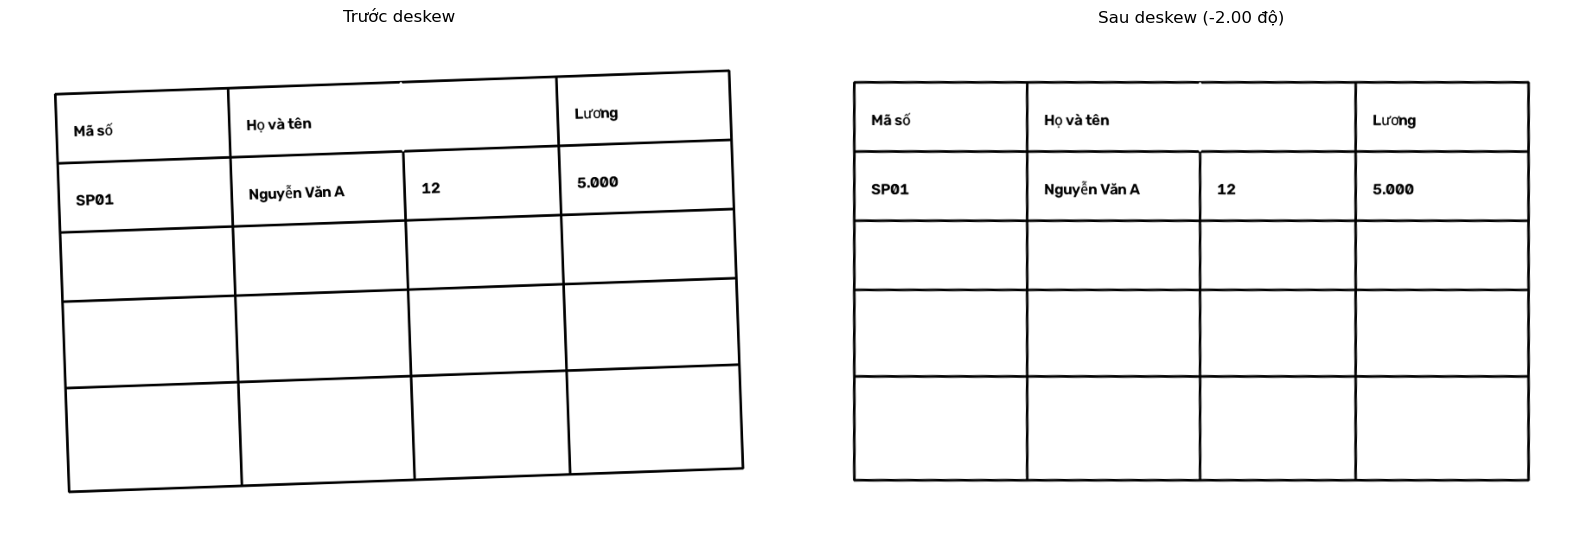

In [7]:
def get_skew_angle_minarearect(gray_img):
    """Ước lượng góc nghiêng bằng hình chữ nhật xoay nhỏ nhất."""
    # Nhị phân tạm: đối tượng (chữ, đường kẻ) thành trắng
    _, bw = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    ys_, xs_ = np.where(bw > 0)
    if len(xs_) == 0:
        return 0.0
    # minAreaRect cần tọa độ dạng (x, y) -> phải đảo thứ tự
    coords = np.column_stack([xs_, ys_]).astype(np.float32)
    angle = cv2.minAreaRect(coords)[-1]
    # Đưa góc về khoảng (-45, 45]
    if angle > 45:
        angle -= 90
    if angle < -45:
        angle += 90
    return angle

angle = get_skew_angle_minarearect(gray)
print(f"Góc nghiêng ước lượng: {angle:.2f} độ")

# An toàn: Chỉ chỉnh góc nhỏ, tránh xoay ảnh 90 độ
if abs(angle) > 10:
    print("Góc ước lượng quá lớn.")
    angle = 0.0

deskewed = rotate(gray, angle)
show_row([gray, deskewed], ["Trước deskew", f"Sau deskew ({angle:.2f} độ)"])

## 2.2. Chỉnh nghiêng bằng Hough Transform

- **Ý tưởng:** Dò ra từng đường thẳng riêng biệt, đo góc của từng đường rồi lấy trung vị.

### Biểu diễn đường thẳng bằng tọa độ cực

Biểu diễn một đường thẳng không dùng `y = ax + b` mà dùng tọa độ cực:

$$\rho = x\cos\theta + y\sin\theta$$

![Hough Transform](images/hough.png)

![Hough Transform](images/hough_2.png)

Trong đó:

- ρ: khoảng cách từ gốc tọa độ tới đường thẳng

- θ: góc của pháp tuyến (đường vuông góc) với trục x

**Tại sao không dùng `y = ax + b`?** Với đường thẳng đứng, hệ số góc `a → ∞` nên không biểu diễn được.
Còn cặp `(ρ, θ)` luôn hữu hạn: `θ ∈ [0, π)`, `|ρ| ≤ đường chéo ảnh`. Mọi đường thẳng đều có đúng một cặp `(ρ, θ)`.

### Không gian Hough và cơ chế bỏ phiếu

![Hough Transform](images/hough_3.png)

Đổi góc nhìn:

| Không gian ảnh `(x, y)` | Không gian Hough `(ρ, θ)` |
|---|---|
| Một **đường thẳng** | Một **điểm** |
| Một **điểm** `(x₀, y₀)` | Một **đường sin** `ρ = x₀cosθ + y₀sinθ` (tập mọi đường thẳng đi qua điểm đó) |
| Nhiều điểm **thẳng hàng** | Nhiều đường sin **cắt nhau tại một điểm** |

Thuật toán:

1. Chia không gian `(ρ, θ)` thành lưới ô, gọi là **accumulator** (mảng 2D ban đầu toàn 0).
   Độ mịn của lưới được quyết định bởi tham số `rho` (px) và `theta` (rad).
2. Với mỗi điểm biên `(x, y)`, duyệt mọi `θ`, tính `ρ`, rồi **+1 phiếu** cho ô `(ρ, θ)` tương ứng.
3. Những ô có số phiếu ≥ `threshold` là một đường thẳng trong ảnh.

Vì vậy phải chạy **Canny trước**: Hough chỉ nhận điểm biên (ảnh nhị phân), và càng ít điểm thì bỏ phiếu càng nhanh.

### `HoughLines` và `HoughLinesP`

| Hàm | Trả về | Đặc điểm |
|---|---|---|
| `cv2.HoughLines` | Các cặp `(ρ, θ)` | Đường thẳng **vô hạn**, không biết đầu mút. Chữ in thẳng hàng cũng có thể tạo ra đường giả |
| `cv2.HoughLinesP` | Các đoạn `(x1, y1, x2, y2)` | Bản *Probabilistic*: chỉ bỏ phiếu trên một tập điểm lấy mẫu ngẫu nhiên nên nhanh hơn. Trả về **đoạn thẳng có đầu mút**, lọc được theo độ dài |

Các tham số:

- `rho=1`, `theta=np.pi/180`: độ phân giải của accumulator là 1 px và 1°. Độ phân giải góc giới hạn độ chính xác của từng đoạn,
  nhưng lấy trung vị nhiều đoạn sẽ cho kết quả mịn hơn 1°.
- `threshold`: số phiếu tối thiểu. Đặt thấp thì ra nhiều đường giả, đặt cao thì mất đường mờ.
- `minLineLength`: độ dài tối thiểu của đoạn thẳng.
- `maxLineGap`: nối hai đoạn nằm trên cùng một đường nếu khoảng hở giữa chúng nhỏ hơn giá trị này. Giúp đường kẻ bị đứt nét vẫn được nhận là một đường.

### Từ đoạn thẳng ra góc nghiêng

Với mỗi đoạn `(x1, y1, x2, y2)`:

$$\alpha = \arctan2(y_2 - y_1,\ x_2 - x_1)$$

- Chuẩn hóa `α` về `(-90°, 90°]`, vì một đoạn thẳng không có hướng: vẽ từ trái sang phải hay từ phải sang trái đều là cùng một đường.
- Chỉ giữ các đoạn **gần ngang** (`|α| ≤ max_angle`). Đường kẻ dọc có góc gần ±90° và sẽ làm lệch kết quả nếu trộn vào.
- Lấy **trung vị** thay vì trung bình: vài đoạn sai (chữ, gạch chân lệch, nhiễu) không kéo lệch được kết quả.

Lưu ý dấu: trong ảnh trục `y` hướng **xuống**, nên `α > 0` nghĩa là đường đi xuống khi sang phải.
Trong `cv2.getRotationMatrix2D`, góc dương là xoay **ngược chiều kim đồng hồ** trên màn hình,
nên xoay ảnh đúng một góc `α` sẽ đưa đường kẻ về nằm ngang.

### So với `minAreaRect`

- **Ưu điểm:** ít bị ảnh hưởng bởi nhiễu, logo, vết bẩn hay chữ lệch lề, vì chỉ tính các đoạn thẳng dài.
  `minAreaRect` thì bị kéo lệch bởi bất kỳ điểm tối nào nằm ngoài vùng bảng.
- **Nhược điểm:** cần bảng có đường kẻ rõ. Bảng không có viền hoặc ảnh quá mờ thì Hough có thể không tìm được đường nào (hàm trả về `0.0`).
  Ngoài ra phải chỉnh tham số (`threshold`, `minLineLength`) theo kích thước ảnh.

Góc nghiêng ước lượng: -1.98 độ


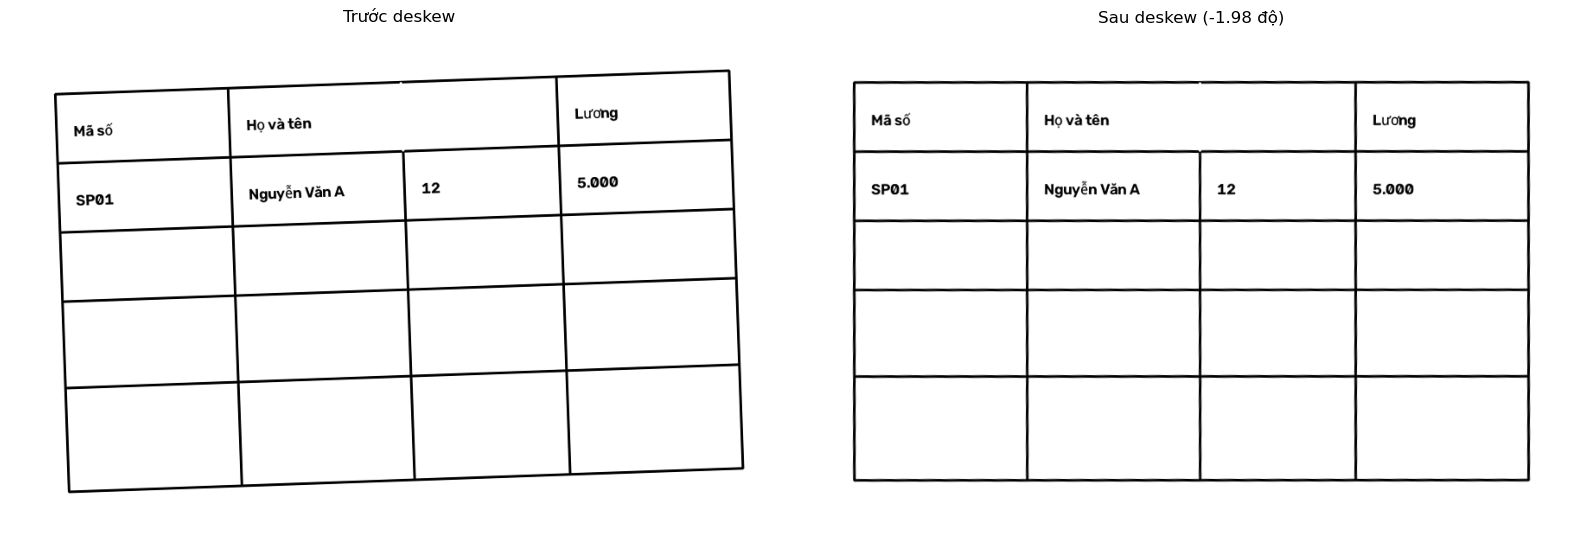

In [10]:
def get_skew_angle_hough(gray_img, max_angle=15.0):
    """Ước lượng góc nghiêng bằng Hough Transform trên các đường gần ngang"""
    # Tách biên
    edges = cv2.Canny(gray_img, 50, 150, apertureSize=3)
    h, w = gray_img.shape[:2]

    # Dò các đoạn thẳng
    lines = cv2.HoughLinesP(
        edges,
        rho=1,
        theta=np.pi/180,
        threshold=100, # số phiếu tối thiểu để công nhận 1 đường
        minLineLength=w//4, # ngắn hơn -> bỏ (loại nét chữ, giữ đường kẻ)
        maxLineGap=20, # nối 2 đoạn cách nhau < 20px thành 1
    )
    if lines is None:
        return 0.0

    # Đo góc từng đoạn, chỉ giữ đoạn gần ngang
    angles = []
    for x1, y1, x2, y2 in lines.reshape(-1, 4):
        a = np.degrees(np.arctan2(y2-y1, x2-x1))
        if a > 90:
            a -= 180
        elif a <= -90:
            a += 180
        if (abs(a) <= max_angle):
            angles.append(a)

    if not angles:
        return 0.0

    return float(np.median(angles)) 

angle = get_skew_angle_hough(gray)
print(f"Góc nghiêng ước lượng: {angle:.2f} độ")

# An toàn: Chỉ chỉnh góc nhỏ, tránh xoay ảnh 90 độ
if abs(angle) > 10:
    print("Góc ước lượng quá lớn.")
    angle = 0.0

deskewed = rotate(gray, angle)
show_row([gray, deskewed], ["Trước deskew", f"Sau deskew ({angle:.2f} độ)"])

# 3. CLAHE - cân bằng sáng cục bộ
**CLAHE** = *Contrast Limited Adaptive Histogram Equalization*.

- **Histogram Equalization:** kéo giãn histogram để dùng hết dải 0–255 → ảnh tương phản hơn.
- **Adaptive:** làm riêng cho từng ô nhỏ (`tileGridSize`) thay vì cả ảnh, để vùng bị bóng đổ
  cũng được kéo sáng. Sau đó nội suy giữa các ô để không thấy đường ranh giới.
- **Contrast Limited:** `clipLimit` giới hạn mức khuếch đại, nếu không nhiễu ở vùng phẳng sẽ bị thổi lên.

Bước này rất quan trọng với **ảnh chụp bằng điện thoại**. Với ảnh scan sạch thì tác dụng ít hơn.